In [1]:
import pandas as pd
import numpy as np

data_dir = "Past Match Data/"

files = {
    "Singapore Smash 2024": "Singapore Smash 2024.csv",
    "Saudi Smash 2024": "Saudi Smash 2024.csv",
    "World Cup Macau 2024": "World Cup Macau 2024.csv",
    "WTT Champions Incheon 2024": "WTT Champions Incheon 2024.csv",
    "WTT Champions Chongqing 2024": "WTT Champions Chongqing 2024.csv",
    "WTT Star Contender Doha 2024": "WTT Star Contender Doha 2024.csv",
    "WTT Star Contender Goa 2024": "WTT Star Contender Goa 2024.csv",
    "WTT Star Contender Ljubljana 2024": "WTT Star Contender Ljubljana 2024.csv",
    "WTT Star Contender Bangkok 2024": "WTT Star Contender Bangkok 2024.csv",
}

dfs = []
for tournament, fn in files.items():
    d = pd.read_csv(data_dir + fn)
    d["Tournament"] = tournament
    dfs.append(d)

raw = pd.concat(dfs, ignore_index=True)
print(raw.shape)
raw.head()

(455, 5)


,Player 1,Player 2,Winner (1 or 2),Scores,Tournament
0,FAN Zhendong,Finn LUU,1.0,3-0,Singapore Smash 2024
1,LIN Shidong,AN Jaehyun,1.0,3-1,Singapore Smash 2024
2,Timo BOLL,CHEW Zhe Yu Clarence,1.0,3-1,Singapore Smash 2024
3,Edward LY,Anton KALLBERG,2.0,0-3,Singapore Smash 2024
4,Tomokazu HARIMOTO,Ruwen FILUS,1.0,3-1,Singapore Smash 2024


In [2]:
raw["Player 1"] = raw["Player 1"].str.strip().str.upper()
raw["Player 2"] = raw["Player 2"].str.strip().str.upper()

raw.head()

,Player 1,Player 2,Winner (1 or 2),Scores,Tournament
0,FAN ZHENDONG,FINN LUU,1.0,3-0,Singapore Smash 2024
1,LIN SHIDONG,AN JAEHYUN,1.0,3-1,Singapore Smash 2024
2,TIMO BOLL,CHEW ZHE YU CLARENCE,1.0,3-1,Singapore Smash 2024
3,EDWARD LY,ANTON KALLBERG,2.0,0-3,Singapore Smash 2024
4,TOMOKAZU HARIMOTO,RUWEN FILUS,1.0,3-1,Singapore Smash 2024


In [3]:
clean = raw[(raw["Player 1"] != "BYE") & (raw["Player 2"] != "BYE")].copy()
print(f"Removed {len(raw) - len(clean)} BYE rows -> {len(clean)} matches remain")

Removed 65 BYE rows -> 390 matches remain


In [4]:
clean["WinnerName"] = np.where(
    clean["Winner (1 or 2)"] == 1,
    clean["Player 1"],
    clean["Player 2"]
)

clean[["Player 1", "Player 2", "Winner (1 or 2)", "WinnerName"]].head()

,Player 1,Player 2,Winner (1 or 2),WinnerName
0,FAN ZHENDONG,FINN LUU,1.0,FAN ZHENDONG
1,LIN SHIDONG,AN JAEHYUN,1.0,LIN SHIDONG
2,TIMO BOLL,CHEW ZHE YU CLARENCE,1.0,TIMO BOLL
3,EDWARD LY,ANTON KALLBERG,2.0,ANTON KALLBERG
4,TOMOKAZU HARIMOTO,RUWEN FILUS,1.0,TOMOKAZU HARIMOTO


In [5]:
counts = pd.concat([clean["Player 1"], clean["Player 2"]]).value_counts()

low = counts[counts < 3]
print(f"Players with <3 matches: {len(low)}")

clean_final = clean[
    clean["Player 1"].map(counts).ge(3) &
    clean["Player 2"].map(counts).ge(3)
].copy()

print(f"Final matches: {len(clean_final)}, unique players: {pd.concat([clean_final['Player 1'], clean_final['Player 2']]).nunique()}")

Players with <3 matches: 51
Final matches: 328, unique players: 70


In [6]:
counts = pd.concat([clean["Player 1"], clean["Player 2"]]).value_counts()
wins = clean["WinnerName"].value_counts()

player_stats = pd.DataFrame({
    "Player": counts.index,
    "Matches": counts.values
})
player_stats["Wins"] = player_stats["Player"].map(wins).fillna(0).astype(int)
player_stats["WinRate"] = (player_stats["Wins"] / player_stats["Matches"]).round(3)

player_stats = player_stats[player_stats["Matches"] >= 3].reset_index(drop=True)

print(f"Final matches dataset: {len(clean)}")
print(f"Players with win rate data (>=3 matches): {len(player_stats)}")
player_stats.sort_values("WinRate", ascending=False).head(10)

Final matches dataset: 390
Players with win rate data (>=3 matches): 70


,Player,Matches,Wins,WinRate
3,WANG CHUQIN,24,22,0.917
0,FELIX LEBRUN,26,20,0.769
4,LIANG JINGKUN,21,16,0.762
62,LIAO CHENG-TING,4,3,0.750
7,FAN ZHENDONG,19,14,0.737
13,MA LONG,15,11,0.733
1,HUGO CALDERANO,26,19,0.731
2,TOMOKAZU HARIMOTO,25,18,0.720
16,LIN SHIDONG,14,10,0.714
8,LIN GAOYUAN,19,13,0.684


In [7]:
clean.to_csv("clean_matches.csv", index=False)
player_stats.to_csv("player_stats.csv", index=False)

print("Saved clean_matches.csv:", clean.shape)
print("Saved player_stats.csv:", player_stats.shape)

Saved clean_matches.csv: (390, 6)
Saved player_stats.csv: (70, 4)


In [8]:
draw = pd.read_csv("Past Match Data/paris2024_draw.csv")
draw["Player"] = draw["Player"].str.strip().str.upper()

print("Olympic players in draw:", len(draw))

merged = draw.merge(player_stats, on="Player", how="left")
matched = merged["WinRate"].notna().sum()
print(f"Matched to player_stats: {matched} / {len(draw)}")

missing = merged[merged["WinRate"].isna()][["Seed", "Player", "Result"]]
missing

Olympic players in draw: 49
Matched to player_stats: 30 / 49


,Seed,Player,Result
7,8,JANG WOO-JIN,Quarterfinal
14,15,CHO DAE-SEONG,First round
18,19,TRULS MOREGARDH,Silver
25,26,FINN LUU,First round
28,29,MOHAMED EL-BEIALI,First round
30,31,NOSHAD ALAMIAN,Second round
32,33,ANDY PEREIRA,First round
33,34,NICOLAS BURGOS,First round
38,39,WANG YANG,First round
39,40,EDUARD IONESCU,Second round


In [9]:
name_fixes = {
    "JANG WOO-JIN": "JANG WOOJIN",
    "CHO DAE-SEONG": "CHO DAESEONG",
    "TRULS MOREGARDH": "TRULS MOREGARD",
    "NOSHAD ALAMIAN": "NOSHAD ALAMIYAN",
    "WANG YANG": "YANG WANG",
    "IZAAC QUEK": "QUEK IZAAC",
}

draw["Player_lookup"] = draw["Player"].replace(name_fixes)

merged = draw.merge(
    player_stats, left_on="Player_lookup", right_on="Player", how="left",
    suffixes=("", "_stats")
)
merged["Player"] = draw["Player"]  # keep original draw spelling for display

matched = merged["WinRate"].notna().sum()
print(f"Matched to player_stats: {matched} / {len(draw)}")

still_missing = merged[merged["WinRate"].isna()][["Seed", "Player", "Result"]]
still_missing

Matched to player_stats: 35 / 49


,Seed,Player,Result
25,26,FINN LUU,First round
28,29,MOHAMED EL-BEIALI,First round
32,33,ANDY PEREIRA,First round
33,34,NICOLAS BURGOS,First round
38,39,WANG YANG,First round
39,40,EDUARD IONESCU,Second round
40,41,MILOSZ REDZIMSKI,Second round
41,42,BRIAN AFANADOR,First round
42,43,ALBERTO MINO,Second round
43,44,MARTIN ALLEGRO,First round


In [10]:
median_winrate = player_stats["WinRate"].median()

merged["WinRate"] = merged["WinRate"].fillna(median_winrate)
merged["Matches"] = merged["Matches"].fillna(0)
merged["Wins"] = merged["Wins"].fillna(0)

print(f"Median WinRate used for imputation: {median_winrate}")
print(f"Players now with a WinRate value: {merged['WinRate'].notna().sum()} / {len(merged)}")

Median WinRate used for imputation: 0.4645
Players now with a WinRate value: 49 / 49


In [11]:
merged.to_csv("draw_with_winrate.csv", index=False)
print("Saved draw_with_winrate.csv:", merged.shape)
merged[["Seed", "Player", "Matches", "Wins", "WinRate", "Result"]].sort_values("WinRate", ascending=False).head(10)

Saved draw_with_winrate.csv: (49, 15)


,Seed,Player,Matches,Wins,WinRate,Result
0,1,WANG CHUQIN,24.0,22.0,0.917,Second round
2,3,FELIX LEBRUN,26.0,20.0,0.769,Bronze
1,2,FAN ZHENDONG,19.0,14.0,0.737,Champion
3,4,HUGO CALDERANO,26.0,19.0,0.731,Fourth place
5,6,TOMOKAZU HARIMOTO,25.0,18.0,0.720,Quarterfinal
6,7,DANG QIU,21.0,14.0,0.667,Second round
4,5,LIN YUN-JU,19.0,12.0,0.632,Quarterfinal
8,9,DIMITRIJ OVTCHAROV,16.0,10.0,0.625,Round of 16
37,38,ANDREJ GACINA,5.0,3.0,0.600,Second round
14,15,CHO DAE-SEONG,16.0,9.0,0.562,First round


In [12]:
winrate_df = pd.read_csv("Feature/Feature1_table_winrate.csv")
winrate_df["Player"] = winrate_df["Player"].str.strip().str.upper()
winrate_df["WinRate"] = winrate_df["Win Rate (%)"] / 100

rank_df = pd.read_csv("Feature/Feature2_World Ranking Points.csv")
rank_df["Name"] = rank_df["Name"].str.strip().str.upper()
rank_df["RankScore"] = rank_df["Points"] / rank_df["Points"].max()

achiev_df = pd.read_csv("Feature/Feature3_career_achievement.csv")
achiev_df["Player"] = achiev_df["Player"].str.strip().str.upper()

print(winrate_df.shape, rank_df.shape, achiev_df.shape)
winrate_df.head()

(74, 6) (229, 5) (49, 4)


,Player,Win,Loss,Total Matches,Win Rate (%),WinRate
0,WANG CHUQIN,17,2,19,89.47,0.8947
1,LIANG JINGKUN,13,4,17,76.47,0.7647
2,FAN ZHENDONG,12,4,16,75.00,0.7500
3,MA LONG,9,3,12,75.00,0.7500
4,DANG QIU,9,4,13,69.23,0.6923


In [13]:
draw = pd.read_csv("Past Match Data/paris2024_draw.csv")
draw["Player"] = draw["Player"].str.strip().str.upper()

draw = draw.merge(winrate_df[["Player", "WinRate"]], on="Player", how="left")
draw = draw.merge(rank_df.rename(columns={"Name": "Player"})[["Player", "RankScore"]], on="Player", how="left")
draw = draw.merge(achiev_df[["Player", "AchievScore"]], on="Player", how="left")

print("Missing WinRate:", draw["WinRate"].isna().sum())
print("Missing RankScore:", draw["RankScore"].isna().sum())
print("Missing AchievScore:", draw["AchievScore"].isna().sum())

draw[["Seed", "Player", "WinRate", "RankScore", "AchievScore", "Result"]].head(10)

Missing WinRate: 14
Missing RankScore: 6
Missing AchievScore: 0


,Seed,Player,WinRate,RankScore,AchievScore,Result
0,1,WANG CHUQIN,0.8947,1.000000,6,Second round
1,2,FAN ZHENDONG,0.7500,0.462082,7,Champion
2,3,FELIX LEBRUN,0.6875,0.452618,5,Bronze
3,4,HUGO CALDERANO,0.6429,0.447319,4,Fourth place
4,5,LIN YUN-JU,0.5833,0.335647,3,Quarterfinal
5,6,TOMOKAZU HARIMOTO,0.6667,0.331861,3,Quarterfinal
6,7,DANG QIU,0.6923,0.254259,3,Second round
7,8,JANG WOO-JIN,NaN,NaN,4,Quarterfinal
8,9,DIMITRIJ OVTCHAROV,0.5556,0.193691,5,Round of 16
9,10,SHUNSUKE TOGAMI,0.2857,0.166562,2,Round of 16


In [14]:
name_fixes = {
    "JANG WOO-JIN": "JANG WOOJIN",
    "CHO DAE-SEONG": "CHO DAESEONG",
    "TRULS MOREGARDH": "TRULS MOREGARD",
    "NOSHAD ALAMIAN": "NOSHAD ALAMIYAN",
    "WANG YANG": "YANG WANG",
    "IZAAC QUEK": "QUEK IZAAC",
}

draw = pd.read_csv("Past Match Data/paris2024_draw.csv")
draw["Player"] = draw["Player"].str.strip().str.upper()
draw["Player_lookup"] = draw["Player"].replace(name_fixes)

draw = draw.merge(winrate_df[["Player", "WinRate"]], left_on="Player_lookup", right_on="Player", how="left", suffixes=("", "_wr"))
draw = draw.merge(rank_df.rename(columns={"Name": "Player"})[["Player", "RankScore"]], left_on="Player_lookup", right_on="Player", how="left", suffixes=("", "_rk"))
draw = draw.merge(achiev_df[["Player", "AchievScore"]], on="Player", how="left")  # original spelling, no lookup

draw = draw.drop(columns=[c for c in draw.columns if c.endswith(("_wr", "_rk"))])

print("Missing WinRate:", draw["WinRate"].isna().sum())
print("Missing RankScore:", draw["RankScore"].isna().sum())
print("Missing AchievScore:", draw["AchievScore"].isna().sum())

draw["WinRate"] = draw["WinRate"].fillna(draw["WinRate"].median())
draw["RankScore"] = draw["RankScore"].fillna(draw["RankScore"].median())
draw["AchievScore"] = draw["AchievScore"].fillna(draw["AchievScore"].median())

draw[["Seed", "Player", "WinRate", "RankScore", "AchievScore", "Result"]].head(10)

Missing WinRate: 9
Missing RankScore: 0
Missing AchievScore: 0


,Seed,Player,WinRate,RankScore,AchievScore,Result
0,1,WANG CHUQIN,0.8947,1.000000,6,Second round
1,2,FAN ZHENDONG,0.7500,0.462082,7,Champion
2,3,FELIX LEBRUN,0.6875,0.452618,5,Bronze
3,4,HUGO CALDERANO,0.6429,0.447319,4,Fourth place
4,5,LIN YUN-JU,0.5833,0.335647,3,Quarterfinal
5,6,TOMOKAZU HARIMOTO,0.6667,0.331861,3,Quarterfinal
6,7,DANG QIU,0.6923,0.254259,3,Second round
7,8,JANG WOO-JIN,0.5833,0.210095,4,Quarterfinal
8,9,DIMITRIJ OVTCHAROV,0.5556,0.193691,5,Round of 16
9,10,SHUNSUKE TOGAMI,0.2857,0.166562,2,Round of 16


In [15]:
draw["AchievScoreNorm"] = draw["AchievScore"] / 7

draw["Score"] = (draw["WinRate"] + draw["RankScore"] + draw["AchievScoreNorm"]) / 3

draw[["Seed", "Player", "WinRate", "RankScore", "AchievScoreNorm", "Score", "Result"]] \
    .sort_values("Score", ascending=False).head(15)

,Seed,Player,WinRate,RankScore,AchievScoreNorm,Score,Result
0,1,WANG CHUQIN,0.8947,1.000000,0.857143,0.917281,Second round
1,2,FAN ZHENDONG,0.7500,0.462082,1.000000,0.737361,Champion
2,3,FELIX LEBRUN,0.6875,0.452618,0.714286,0.618135,Bronze
3,4,HUGO CALDERANO,0.6429,0.447319,0.571429,0.553882,Fourth place
8,9,DIMITRIJ OVTCHAROV,0.5556,0.193691,0.714286,0.487859,Round of 16
5,6,TOMOKAZU HARIMOTO,0.6667,0.331861,0.428571,0.475711,Quarterfinal
6,7,DANG QIU,0.6923,0.254259,0.428571,0.458377,Second round
7,8,JANG WOO-JIN,0.5833,0.210095,0.571429,0.454941,Quarterfinal
4,5,LIN YUN-JU,0.5833,0.335647,0.428571,0.449173,Quarterfinal
14,15,CHO DAE-SEONG,0.6250,0.149527,0.571429,0.448652,First round


In [16]:
draw.to_csv("draw_with_score.csv", index=False)
print("Saved draw_with_score.csv:", draw.shape)

Saved draw_with_score.csv: (49, 16)


In [17]:
draw["Player"] = draw["Player"].replace({"MIŁOSZ REDZIMSKI": "MILOSZ REDZIMSKI"})
for col in ["R64_Opponent","R32_Opponent","R16_Opponent","QF_Opponent","SF_Opponent","F_Opponent"]:
    draw[col] = draw[col].replace({"MIŁOSZ REDZIMSKI": "MILOSZ REDZIMSKI"})

score_lookup = dict(zip(draw["Player"], draw["Score"]))
median_score = draw["Score"].median()
rounds = ["R64_Opponent","R32_Opponent","R16_Opponent","QF_Opponent","SF_Opponent","F_Opponent"]

def difficulty(row):
    total = 0
    for r in rounds:
        opp = row[r]
        if pd.notna(opp) and opp != "BYE":
            total += score_lookup.get(opp, median_score)
    return round(total, 4)

draw["Difficulty"] = draw.apply(difficulty, axis=1)

draw[["Seed", "Player", "Difficulty", "Result"]].sort_values("Difficulty", ascending=False).head(10)

,Seed,Player,Difficulty,Result
18,19,TRULS MOREGARDH,2.7618,Silver
2,3,FELIX LEBRUN,2.4615,Bronze
1,2,FAN ZHENDONG,1.7047,Champion
3,4,HUGO CALDERANO,1.4476,Fourth place
4,5,LIN YUN-JU,1.1808,Quarterfinal
48,59,KANAK JHA,1.1790,Round of 16
7,8,JANG WOO-JIN,1.1065,Quarterfinal
5,6,TOMOKAZU HARIMOTO,1.0849,Quarterfinal
38,39,WANG YANG,0.9173,First round
8,9,DIMITRIJ OVTCHAROV,0.7873,Round of 16


In [18]:
from scipy.stats import linregress

slope, intercept, r, p, se = linregress(draw["Seed"], draw["Difficulty"])

draw["ExpectedDifficulty"] = (intercept + slope * draw["Seed"]).round(4)
draw["Fortune"] = (draw["ExpectedDifficulty"] - draw["Difficulty"]).round(4)

print(f"R² = {r**2:.3f}  (paper reports 0.180)")
print(f"slope = {slope:.4f}, intercept = {intercept:.4f}")

draw[["Seed", "Player", "Difficulty", "ExpectedDifficulty", "Fortune", "Result"]] \
    .sort_values("Fortune", ascending=False).head(10)

R² = 0.172  (paper reports 0.180)
slope = -0.0173, intercept = 0.9476


,Seed,Player,Difficulty,ExpectedDifficulty,Fortune,Result
11,12,MARCOS FREITAS,0.000,0.7395,0.7395,First round
6,7,DANG QIU,0.118,0.8262,0.7082,Second round
13,14,QUADRI ARUNA,0.000,0.7048,0.7048,First round
14,15,CHO DAE-SEONG,0.000,0.6875,0.6875,First round
21,22,EDWARD LY,0.000,0.5661,0.5661,First round
22,23,NICHOLAS LUM,0.000,0.5488,0.5488,First round
23,24,SHARATH KAMAL ACHANTA,0.000,0.5315,0.5315,First round
25,26,FINN LUU,0.000,0.4968,0.4968,First round
26,27,OVIDIU IONESCU,0.000,0.4794,0.4794,First round
28,29,MOHAMED EL-BEIALI,0.000,0.4448,0.4448,First round


In [19]:
median_score = draw["Score"].median()
draw.loc[draw["Difficulty"] == 0, "Difficulty"] = round(median_score, 4)

from scipy.stats import linregress

slope, intercept, r, p, se = linregress(draw["Seed"], draw["Difficulty"])

draw["ExpectedDifficulty"] = (intercept + slope * draw["Seed"]).round(4)
draw["Fortune"] = (draw["ExpectedDifficulty"] - draw["Difficulty"]).round(4)

print(f"R² = {r**2:.3f}  (paper reports 0.180)")
print(f"slope = {slope:.4f}, intercept = {intercept:.4f}  (paper: -0.017, 1.173)")

draw[["Seed", "Player", "Difficulty", "ExpectedDifficulty", "Fortune", "Result"]] \
    .sort_values("Fortune", ascending=False).head(10)

R² = 0.173  (paper reports 0.180)
slope = -0.0158, intercept = 0.9812  (paper: -0.017, 1.173)


,Seed,Player,Difficulty,ExpectedDifficulty,Fortune,Result
6,7,DANG QIU,0.1180,0.8705,0.7525,Second round
11,12,MARCOS FREITAS,0.2208,0.7915,0.5707,First round
13,14,QUADRI ARUNA,0.2208,0.7598,0.5390,First round
14,15,CHO DAE-SEONG,0.2208,0.7440,0.5232,First round
21,22,EDWARD LY,0.2208,0.6333,0.4125,First round
22,23,NICHOLAS LUM,0.2208,0.6175,0.3967,First round
23,24,SHARATH KAMAL ACHANTA,0.2208,0.6017,0.3809,First round
25,26,FINN LUU,0.2208,0.5701,0.3493,First round
26,27,OVIDIU IONESCU,0.2208,0.5543,0.3335,First round
33,34,NICOLAS BURGOS,0.1180,0.4436,0.3256,First round


In [20]:
draw.to_csv("draw_with_fortune.csv", index=False)
print("Saved draw_with_fortune.csv:", draw.shape)

Saved draw_with_fortune.csv: (49, 19)


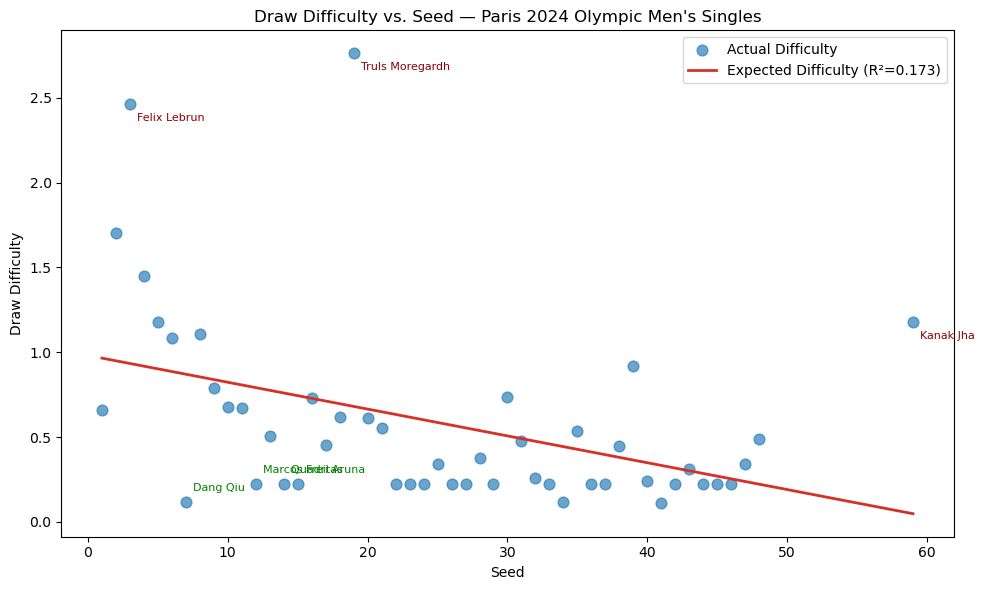

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(draw["Seed"], draw["Difficulty"], alpha=0.7, s=60, color="#2c7fb8", label="Actual Difficulty")
ax.plot(draw["Seed"].sort_values(), intercept + slope * draw["Seed"].sort_values(),
        color="#d73027", linewidth=2, label=f"Expected Difficulty (R²={r**2:.3f})")

for _, row in draw.nlargest(3, "Fortune").iterrows():
    ax.annotate(row["Player"].title(), (row["Seed"], row["Difficulty"]),
                textcoords="offset points", xytext=(5, 8), fontsize=8, color="green")
for _, row in draw.nsmallest(3, "Fortune").iterrows():
    ax.annotate(row["Player"].title(), (row["Seed"], row["Difficulty"]),
                textcoords="offset points", xytext=(5, -12), fontsize=8, color="darkred")

ax.set_xlabel("Seed")
ax.set_ylabel("Draw Difficulty")
ax.set_title("Draw Difficulty vs. Seed — Paris 2024 Olympic Men's Singles")
ax.legend()
plt.tight_layout()
plt.savefig("fortune_regression.png", dpi=150)
plt.show()

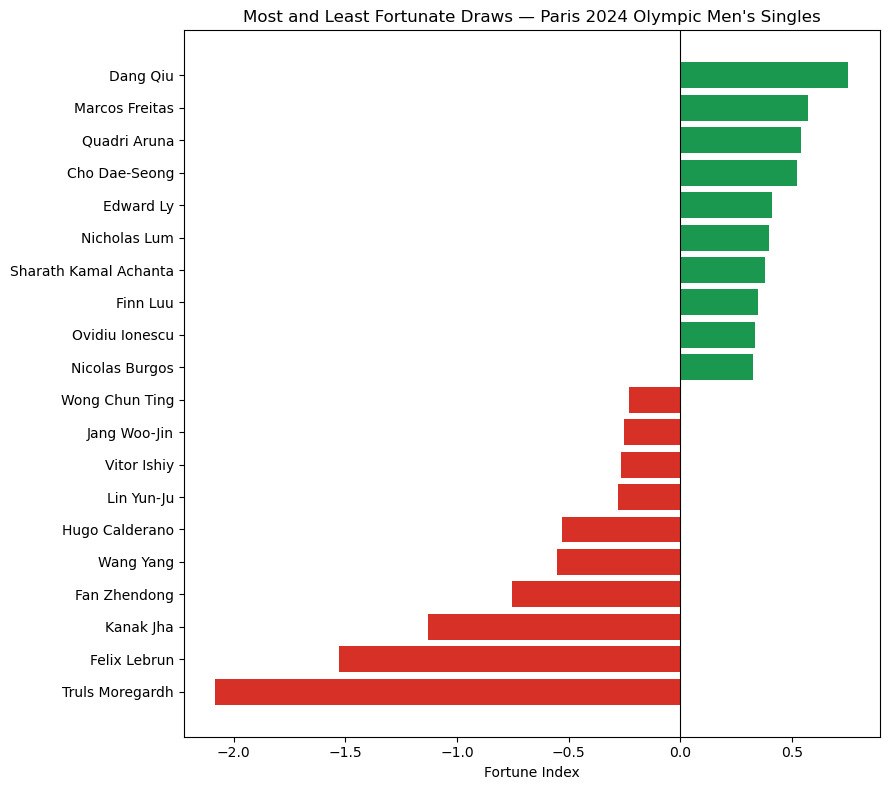

In [22]:
draw["Result"] = draw["Result"].str.strip()

top10 = draw.nlargest(10, "Fortune")[["Player", "Fortune"]]
bottom10 = draw.nsmallest(10, "Fortune")[["Player", "Fortune"]]
fortune_extremes = pd.concat([top10, bottom10]).sort_values("Fortune")

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#d73027" if v < 0 else "#1a9850" for v in fortune_extremes["Fortune"]]
ax.barh(fortune_extremes["Player"].str.title(), fortune_extremes["Fortune"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Fortune Index")
ax.set_title("Most and Least Fortunate Draws — Paris 2024 Olympic Men's Singles")
plt.tight_layout()
plt.savefig("fortune_ranking.png", dpi=150)
plt.show()

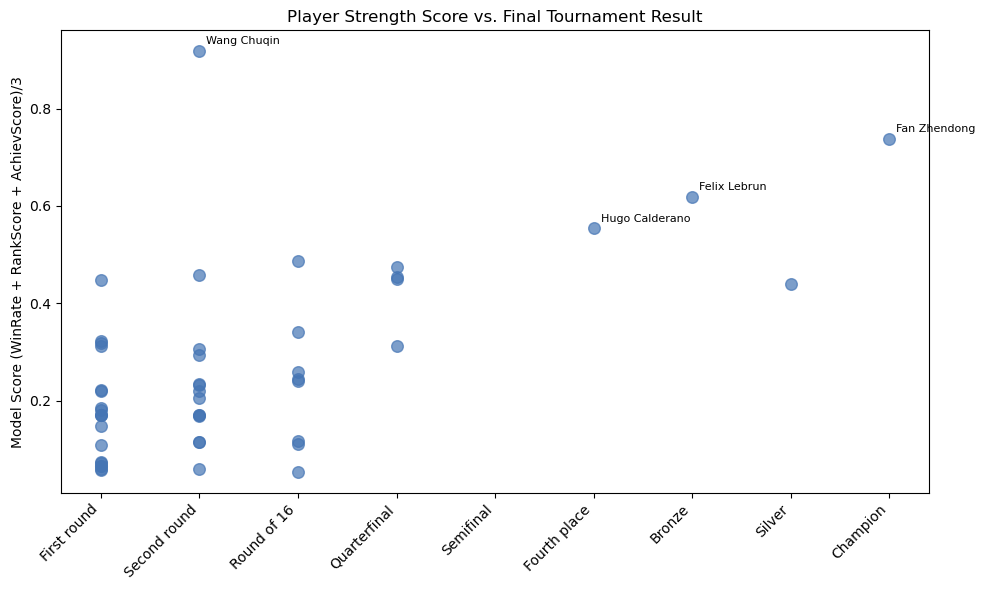

In [23]:
draw["Result"] = draw["Result"].str.strip()
result_order = ["First round", "Second round", "Round of 16", "Quarterfinal",
                 "Semifinal", "Fourth place", "Bronze", "Silver", "Champion"]
draw["Result"] = pd.Categorical(draw["Result"], categories=result_order, ordered=True)
draw["Result_code"] = draw["Result"].cat.codes

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(draw["Result_code"], draw["Score"], alpha=0.7, s=70, color="#4575b4")

for _, row in draw[draw["Score"] > 0.55].iterrows():
    ax.annotate(row["Player"].title(), (row["Result_code"], row["Score"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xticks(range(len(result_order)))
ax.set_xticklabels(result_order, rotation=45, ha="right")
ax.set_ylabel("Model Score (WinRate + RankScore + AchievScore)/3")
ax.set_title("Player Strength Score vs. Final Tournament Result")
plt.tight_layout()
plt.savefig("score_vs_result.png", dpi=150)
plt.show()

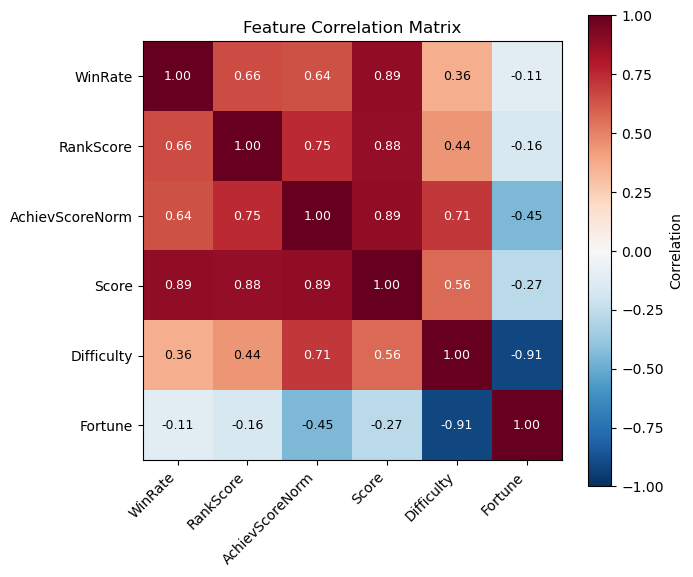

In [24]:
cols = ["WinRate", "RankScore", "AchievScoreNorm", "Score", "Difficulty", "Fortune"]
corr = draw[cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=9)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

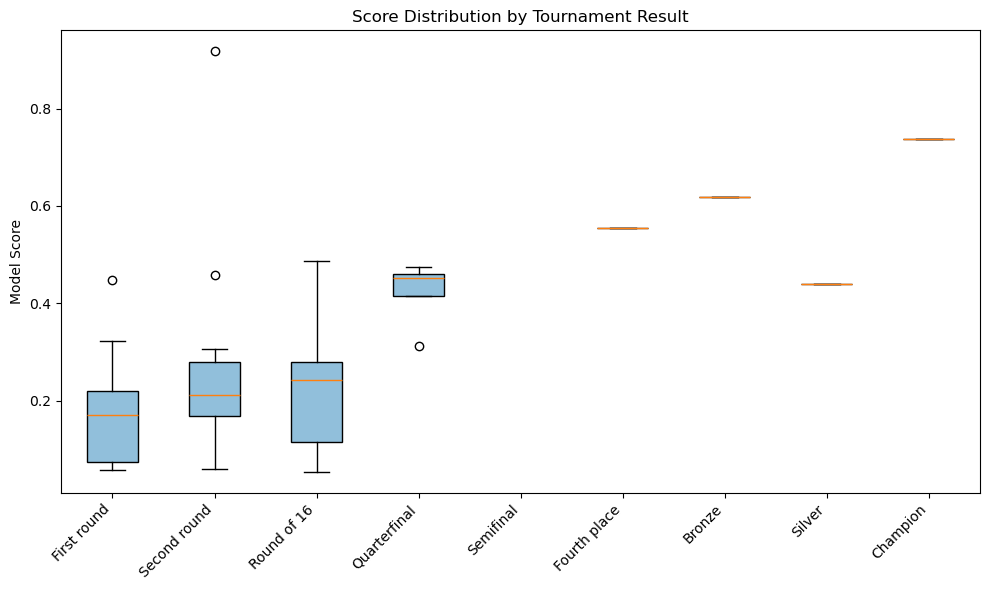

In [25]:
result_order = ["First round", "Second round", "Round of 16", "Quarterfinal",
                 "Semifinal", "Fourth place", "Bronze", "Silver", "Champion"]
groups = [draw[draw["Result"] == r]["Score"].dropna() for r in result_order]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(groups, tick_labels=result_order, patch_artist=True,
           boxprops=dict(facecolor="#91bfdb"))
ax.set_xticklabels(result_order, rotation=45, ha="right")
ax.set_ylabel("Model Score")
ax.set_title("Score Distribution by Tournament Result")
plt.tight_layout()
plt.savefig("score_boxplot.png", dpi=150)
plt.show()

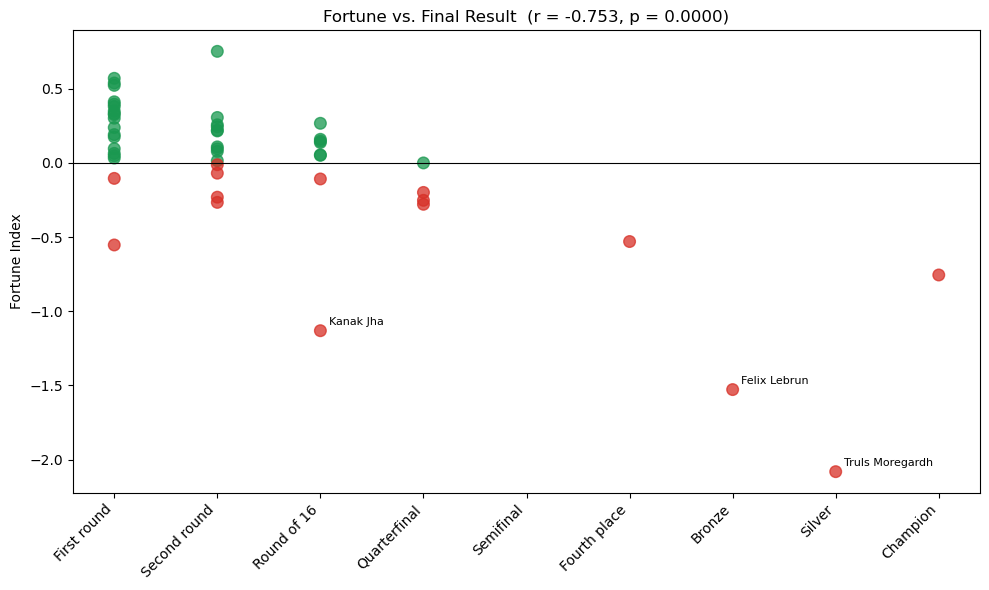

In [26]:
draw["Result"] = draw["Result"].str.strip()
result_order = ["First round", "Second round", "Round of 16", "Quarterfinal",
                 "Semifinal", "Fourth place", "Bronze", "Silver", "Champion"]
draw["Result"] = pd.Categorical(draw["Result"], categories=result_order, ordered=True)
draw["Result_code"] = draw["Result"].cat.codes

from scipy.stats import pearsonr
r_val, p_val = pearsonr(draw["Result_code"], draw["Fortune"])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d73027" if v < 0 else "#1a9850" for v in draw["Fortune"]]
ax.scatter(draw["Result_code"], draw["Fortune"], c=colors, alpha=0.75, s=70)
ax.axhline(0, color="black", linewidth=0.8)

for _, row in draw.loc[draw["Fortune"].abs() > 1].iterrows():
    ax.annotate(row["Player"].title(), (row["Result_code"], row["Fortune"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xticks(range(len(result_order)))
ax.set_xticklabels(result_order, rotation=45, ha="right")
ax.set_ylabel("Fortune Index")
ax.set_title(f"Fortune vs. Final Result  (r = {r_val:.3f}, p = {p_val:.4f})")
plt.tight_layout()
plt.savefig("fortune_vs_result.png", dpi=150)
plt.show()

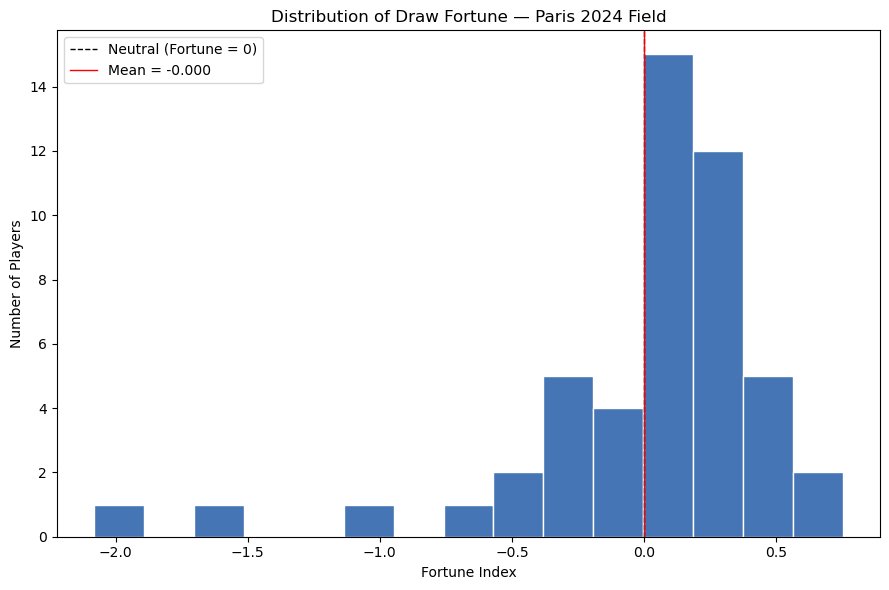

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(draw["Fortune"], bins=15, color="#4575b4", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Neutral (Fortune = 0)")
ax.axvline(draw["Fortune"].mean(), color="red", linestyle="-", linewidth=1,
           label=f"Mean = {draw['Fortune'].mean():.3f}")
ax.set_xlabel("Fortune Index")
ax.set_ylabel("Number of Players")
ax.set_title("Distribution of Draw Fortune — Paris 2024 Field")
ax.legend()
plt.tight_layout()
plt.savefig("fortune_distribution.png", dpi=150)
plt.show()